In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(f"XGBoost version: {xgb.__version__}")
print("All imports successful.")

XGBoost version: 3.1.3
All imports successful.


In [2]:
farm_b_path     = "C:/Users/cjcha/Downloads/CARE_To_Compare/CARE_To_Compare/Wind Farm B"
datasets_path_b = f"{farm_b_path}/datasets"

event_info_b = pd.read_csv(f"{farm_b_path}/event_info.csv", sep=";")

dfs_b = []
for fname in os.listdir(datasets_path_b):
    if fname.endswith(".csv"):
        df_temp             = pd.read_csv(os.path.join(datasets_path_b, fname), sep=";").copy()
        df_temp["event_id"] = int(fname.replace(".csv", ""))
        dfs_b.append(df_temp)

df_raw_b = pd.concat(dfs_b, ignore_index=True)
df_raw_b["event_id"] = df_raw_b["event_id"].astype(int)
df_raw_b = df_raw_b.merge(
    event_info_b[["event_id", "event_label", "event_description"]],
    on="event_id", how="left"
)
df_raw_b["label"] = (df_raw_b["event_label"] == "anomaly").astype(int)

print(f"Farm B rows:    {len(df_raw_b):,}")
print(f"Farm B columns: {len(df_raw_b.columns)}")
print(f"\nLabel distribution:")
print(df_raw_b["label"].value_counts())

Farm B rows:    859,065
Farm B columns: 261

Label distribution:
label
0    505688
1    353377
Name: count, dtype: int64


In [3]:
farm_c_path     = "C:/Users/cjcha/Downloads/CARE_To_Compare/CARE_To_Compare/Wind Farm C"
datasets_path_c = f"{farm_c_path}/datasets"

event_info_c = pd.read_csv(f"{farm_c_path}/event_info.csv", sep=";")

# Load only the columns we need from Farm C
# avoids loading all 957 columns into memory
cols_we_need_c = [
    "time_stamp", "asset_id", "id", "train_test", "status_type_id",
    # Gearbox temperatures
    "sensor_186_avg", "sensor_187_avg",
    "sensor_189_avg", "sensor_190_avg",
    # Rotor and bearing temperatures
    "sensor_196_avg", "sensor_197_avg", "sensor_198_avg",
    "sensor_194_avg", "sensor_195_avg",
    # Transformer temperatures
    "sensor_191_avg", "sensor_192_avg", "sensor_188_avg",
    # Hydraulic
    "sensor_178_avg", "sensor_179_avg",
    # Planetary bearing temperatures
    "sensor_151_avg", "sensor_152_avg",
    "sensor_153_avg", "sensor_154_avg",
    # Stator winding temperatures
    "sensor_199_avg", "sensor_200_avg",
    "sensor_201_avg", "sensor_202_avg",
    # Operational
    "sensor_144_avg", "sensor_177_avg", "wind_speed_235_avg",
]

dfs_c = []
for fname in os.listdir(datasets_path_c):
    if fname.endswith(".csv"):
        df_temp = pd.read_csv(
            os.path.join(datasets_path_c, fname),
            sep=";",
            usecols=lambda col: col in cols_we_need_c
        ).copy()
        df_temp["event_id"] = int(fname.replace(".csv", ""))
        dfs_c.append(df_temp)

df_raw_c = pd.concat(dfs_c, ignore_index=True)
df_raw_c["event_id"] = df_raw_c["event_id"].astype(int)
df_raw_c = df_raw_c.merge(
    event_info_c[["event_id", "event_label", "event_description"]],
    on="event_id", how="left"
)
df_raw_c["label"] = (df_raw_c["event_label"] == "anomaly").astype(int)

print(f"Farm C rows:    {len(df_raw_c):,}")
print(f"Farm C columns: {len(df_raw_c.columns)}")
print(f"\nLabel distribution:")
print(df_raw_c["label"].value_counts())

Farm C rows:    3,187,136
Farm C columns: 34

Label distribution:
label
0    1698911
1    1488225
Name: count, dtype: int64


In [4]:
train_b = df_raw_b[df_raw_b["train_test"] == "train"].copy()
pred_b  = df_raw_b[df_raw_b["train_test"] == "prediction"].copy()

train_c = df_raw_c[df_raw_c["train_test"] == "train"].copy()
pred_c  = df_raw_c[df_raw_c["train_test"] == "prediction"].copy()

print(f"Farm B — train: {len(train_b):,}  pred: {len(pred_b):,}")
print(f"Farm C — train: {len(train_c):,}  pred: {len(pred_c):,}")
print(f"\nFarm B anomaly events: {train_b['label'].sum():,} anomaly rows")
print(f"Farm C anomaly events: {train_c['label'].sum():,} anomaly rows")

Farm B — train: 786,937  pred: 72,128
Farm C — train: 3,028,608  pred: 158,528

Farm B anomaly events: 315,068 anomaly rows
Farm C anomaly events: 1,410,336 anomaly rows


In [5]:
# Shared utility function used by both models
# Rolling windows, rate of change, and z-scores
# Computed per asset_id + event_id so windows never cross boundaries

def engineer_features(df, feature_cols):
    """Add rolling, delta and z-score features per turbine per event."""
    df     = df.sort_values(["asset_id", "event_id", "time_stamp"]).copy()
    groups = df.groupby(["asset_id", "event_id"])

    for col in feature_cols:
        df[f"{col}_roll_mean_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).mean()
        )
        df[f"{col}_roll_std_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).std()
        )
        df[f"{col}_roll_mean_24h"] = groups[col].transform(
            lambda x: x.rolling(144, min_periods=1).mean()
        )
        df[f"{col}_delta"] = groups[col].transform(
            lambda x: x.diff()
        )

    return df


def add_zscores(df_full, df_train, feature_cols):
    """
    Compute per-turbine per-event baseline from training data only
    then apply z-scores to the full DataFrame passed in.
    """
    baseline = (
        df_train.groupby(["asset_id", "event_id"])[feature_cols]
        .agg(["mean", "std"])
    )
    baseline.columns = [f"{col}_{stat}" for col, stat in baseline.columns]
    baseline         = baseline.reset_index()

    df_full = df_full.merge(baseline, on=["asset_id", "event_id"], how="left")

    for col in feature_cols:
        df_full[f"{col}_zscore"] = (
            (df_full[col] - df_full[f"{col}_mean"]) /
            df_full[f"{col}_std"].replace(0, 1)
        )

    return df_full


def build_feature_list(base_sensors):
    """Build full list of engineered feature column names."""
    return (
        base_sensors +
        [f"{c}_roll_mean_6h"  for c in base_sensors] +
        [f"{c}_roll_std_6h"   for c in base_sensors] +
        [f"{c}_roll_mean_24h" for c in base_sensors] +
        [f"{c}_delta"         for c in base_sensors] +
        [f"{c}_zscore"        for c in base_sensors]
    )


print("Feature engineering functions defined.")

Feature engineering functions defined.


In [6]:
# Farm B has 257 features, we use all sensors relevant to
# Farm B's specific fault types: transformer cell temperatures,
# rotor bearing damage, and main bearing damage

farm_b_sensors = [
    "sensor_32_avg",   # generator bearing temperature 1
    "sensor_33_avg",   # generator bearing temperature 2
    "sensor_34_avg",   # gearbox bearing temperature 1
    "sensor_35_avg",   # gearbox bearing temperature 2
    "sensor_36_avg",   # gearbox bearing temperature 3
    "sensor_37_avg",   # gearbox bearing temperature 4
    "sensor_38_avg",   # gearbox oil inlet temperature
    "sensor_39_avg",   # gearbox oil tank temperature
    "sensor_31_avg",   # temperature internal consumption transformer
    "sensor_19_avg",   # generator converter rotational speed
    "sensor_20_avg",   # gearbox rotational speed
    "sensor_25_avg",   # rotor speed
    "sensor_6_avg",    # wind speed
    "sensor_8_avg",    # outside temperature
]

# Only keep sensors that actually exist in Farm B data
farm_b_sensors = [s for s in farm_b_sensors if s in train_b.columns]

print(f"Farm B sensors selected: {len(farm_b_sensors)}")
for s in farm_b_sensors:
    print(f"  {s}")

Farm B sensors selected: 14
  sensor_32_avg
  sensor_33_avg
  sensor_34_avg
  sensor_35_avg
  sensor_36_avg
  sensor_37_avg
  sensor_38_avg
  sensor_39_avg
  sensor_31_avg
  sensor_19_avg
  sensor_20_avg
  sensor_25_avg
  sensor_6_avg
  sensor_8_avg


In [7]:
# Farm C has more diverse fault types: hydraulic, pitch, bearing,
# transformer, converter. We use Farm C specific sensors that
# directly relate to these fault types, not limited to the 10
# shared with Farm B

farm_c_sensors = [
    # Gearbox
    "sensor_186_avg",   # gearbox oil temperature 1
    "sensor_187_avg",   # gearbox oil temperature 2
    "sensor_189_avg",   # gearbox oil inlet temperature 1
    "sensor_190_avg",   # gearbox oil inlet temperature 2
    # Rotor and main bearings
    "sensor_196_avg",   # rotor bearing temperature 1
    "sensor_197_avg",   # rotor bearing temperature 2
    "sensor_198_avg",   # rotor bearing temperature 3
    "sensor_194_avg",   # axis 1 rotor bearing inner ring temperature
    "sensor_195_avg",   # axis 2 rotor bearing inner ring temperature
    # Transformer
    "sensor_191_avg",   # oil temperature 1 main transformer
    "sensor_192_avg",   # oil temperature 2 main transformer
    "sensor_188_avg",   # oil temperature EB transformer
    # Hydraulic
    "sensor_178_avg",   # hydraulic oil tank temperature 1
    "sensor_179_avg",   # hydraulic oil tank temperature 2
    # Planetary bearings
    "sensor_151_avg",   # temperature 1 planetary bearing A1
    "sensor_152_avg",   # temperature 1 planetary bearing A2
    "sensor_153_avg",   # temperature 1 planetary bearing B1
    "sensor_154_avg",   # temperature 1 planetary bearing B2
    # Stator windings
    "sensor_199_avg",   # temperature of stator winding U1
    "sensor_200_avg",   # temperature of stator winding U2
    "sensor_201_avg",   # temperature of stator winding V1
    "sensor_202_avg",   # temperature of stator winding V2
    # Operational
    "sensor_144_avg",   # rotor speed
    "sensor_177_avg",   # outside temperature
    "wind_speed_235_avg", # wind speed
]

# Only keep sensors that actually exist in Farm C data
farm_c_sensors = [s for s in farm_c_sensors if s in train_c.columns]

print(f"Farm C sensors selected: {len(farm_c_sensors)}")
for s in farm_c_sensors:
    print(f"  {s}")

Farm C sensors selected: 25
  sensor_186_avg
  sensor_187_avg
  sensor_189_avg
  sensor_190_avg
  sensor_196_avg
  sensor_197_avg
  sensor_198_avg
  sensor_194_avg
  sensor_195_avg
  sensor_191_avg
  sensor_192_avg
  sensor_188_avg
  sensor_178_avg
  sensor_179_avg
  sensor_151_avg
  sensor_152_avg
  sensor_153_avg
  sensor_154_avg
  sensor_199_avg
  sensor_200_avg
  sensor_201_avg
  sensor_202_avg
  sensor_144_avg
  sensor_177_avg
  wind_speed_235_avg


In [8]:
print("=" * 55)
print("MODEL 1: Farm B XGBoost")
print("=" * 55)

# Engineer training features
print("\nEngineering Farm B training features...")
train_b_eng  = engineer_features(train_b, farm_b_sensors)
train_b_eng  = add_zscores(train_b_eng, train_b_eng, farm_b_sensors)

# Engineer prediction features using training baseline
print("Engineering Farm B prediction features...")
pred_b_eng   = engineer_features(pred_b, farm_b_sensors)
pred_b_eng   = add_zscores(pred_b_eng, train_b_eng, farm_b_sensors)

# Build feature matrix
b_features   = build_feature_list(farm_b_sensors)
b_features   = [f for f in b_features if f in train_b_eng.columns]

X_train_b    = train_b_eng[b_features].fillna(0)
y_train_b    = train_b_eng["label"].values
X_pred_b     = pred_b_eng[b_features].fillna(0)
y_pred_b     = pred_b_eng["label"].values

print(f"\nFarm B features:        {len(b_features)}")
print(f"Farm B training rows:   {len(X_train_b):,}")
print(f"Farm B prediction rows: {len(X_pred_b):,}")

# Class imbalance
b_normal  = (y_train_b == 0).sum()
b_anomaly = (y_train_b == 1).sum()
b_spw     = b_normal / b_anomaly
print(f"\nscale_pos_weight: {b_spw:.2f}")

# Train
print("\nTraining Farm B model...")
model_b = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = b_spw,
    eval_metric      = "aucpr",
    random_state     = 42,
    n_jobs           = -1
)
model_b.fit(X_train_b, y_train_b, verbose=50,
            eval_set=[(X_train_b, y_train_b)])
print("Farm B model trained.")

MODEL 1: Farm B XGBoost

Engineering Farm B training features...
Engineering Farm B prediction features...

Farm B features:        84
Farm B training rows:   786,937
Farm B prediction rows: 72,128

scale_pos_weight: 1.50

Training Farm B model...
[0]	validation_0-aucpr:0.54773
[50]	validation_0-aucpr:0.84964
[100]	validation_0-aucpr:0.88606
[150]	validation_0-aucpr:0.89809
[200]	validation_0-aucpr:0.91427
[250]	validation_0-aucpr:0.92883
[299]	validation_0-aucpr:0.93634
Farm B model trained.


Farm B Accuracy: 86.2%

Detailed breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.90      0.79      0.84     33819
 Anomaly (1)       0.83      0.92      0.88     38309

    accuracy                           0.86     72128
   macro avg       0.87      0.86      0.86     72128
weighted avg       0.87      0.86      0.86     72128



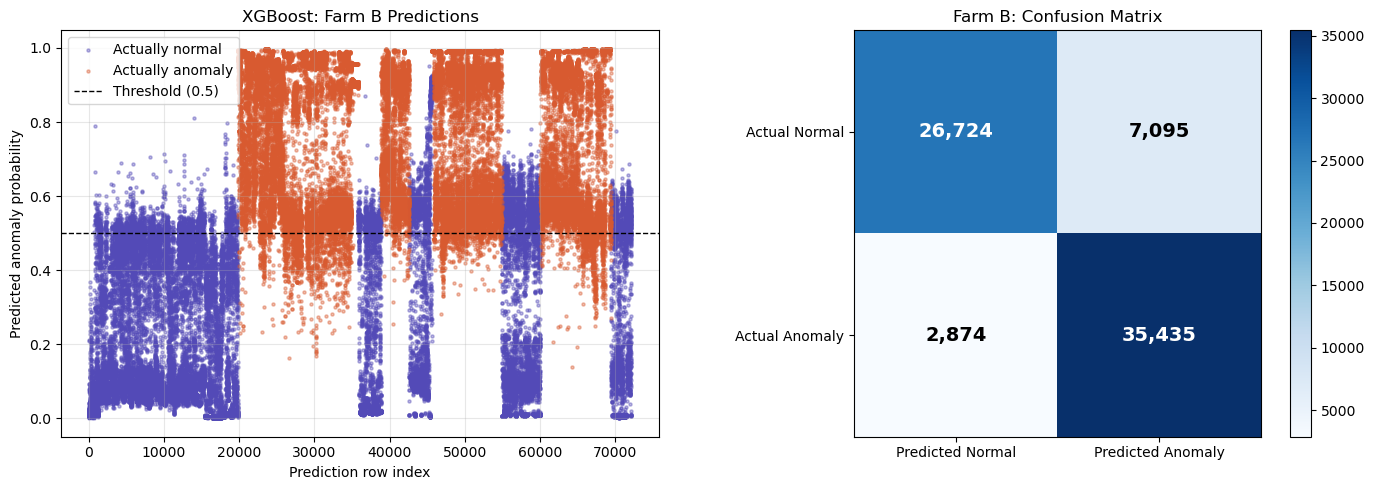

In [9]:
preds_b = model_b.predict(X_pred_b)
probs_b = model_b.predict_proba(X_pred_b)[:, 1]
acc_b   = accuracy_score(y_pred_b, preds_b)

print(f"Farm B Accuracy: {acc_b*100:.1f}%")
print("\nDetailed breakdown:")
print(classification_report(
    y_pred_b, preds_b,
    target_names=["Normal (0)", "Anomaly (1)"]
))

cm_b = confusion_matrix(y_pred_b, preds_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_mask_b  = y_pred_b == 0
anomaly_mask_b = y_pred_b == 1

axes[0].scatter(
    np.where(normal_mask_b)[0],  probs_b[normal_mask_b],
    color="#534AB7", alpha=0.4, s=5, label="Actually normal"
)
axes[0].scatter(
    np.where(anomaly_mask_b)[0], probs_b[anomaly_mask_b],
    color="#D85A30", alpha=0.4, s=5, label="Actually anomaly"
)
axes[0].axhline(y=0.5, color="black", linestyle="--",
                linewidth=1, label="Threshold (0.5)")
axes[0].set_xlabel("Prediction row index")
axes[0].set_ylabel("Predicted anomaly probability")
axes[0].set_title("XGBoost: Farm B Predictions")
axes[0].legend()
axes[0].grid(alpha=0.3)

im = axes[1].imshow(cm_b, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Predicted Normal", "Predicted Anomaly"])
axes[1].set_yticklabels(["Actual Normal", "Actual Anomaly"])
axes[1].set_title("Farm B: Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, f"{cm_b[i,j]:,}", ha="center", va="center",
            color="white" if cm_b[i,j] > cm_b.max()/2 else "black",
            fontsize=14, fontweight="bold"
        )
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("xgb_b_results.png", dpi=150, bbox_inches="tight")
plt.show()

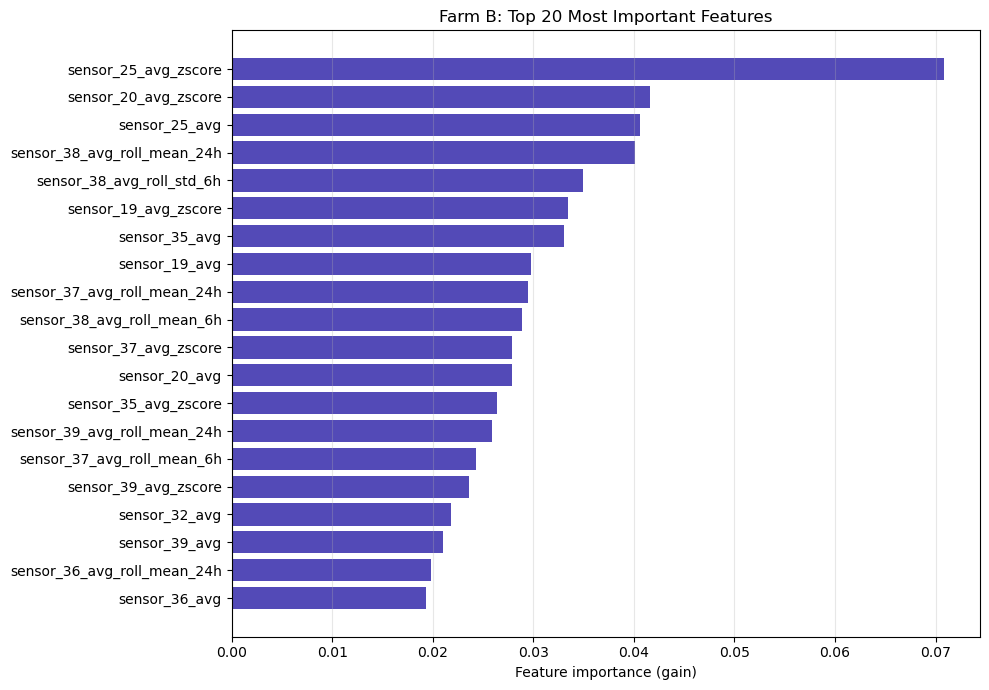

Top 10 Farm B features:
                    feature  importance
       sensor_25_avg_zscore    0.070867
       sensor_20_avg_zscore    0.041585
              sensor_25_avg    0.040564
sensor_38_avg_roll_mean_24h    0.040078
  sensor_38_avg_roll_std_6h    0.034973
       sensor_19_avg_zscore    0.033405
              sensor_35_avg    0.033004
              sensor_19_avg    0.029786
sensor_37_avg_roll_mean_24h    0.029489
 sensor_38_avg_roll_mean_6h    0.028910


In [10]:
b_importance = pd.DataFrame({
    "feature":    b_features,
    "importance": model_b.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20_b = b_importance.head(20)
ax.barh(
    top20_b["feature"][::-1],
    top20_b["importance"][::-1],
    color="#534AB7", edgecolor="none"
)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Farm B: Top 20 Most Important Features")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_b_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 Farm B features:")
print(b_importance[["feature", "importance"]].head(10).to_string(index=False))

Total pred rows:          72,128
Normal operation rows:    67,079
Rows filtered out:        5,049

Anomaly event: % rows above threshold: 39.2%
Normal event: % rows above threshold: 0.1%
Separation:                             39.1 pp
First detection:                        46.8h before fault


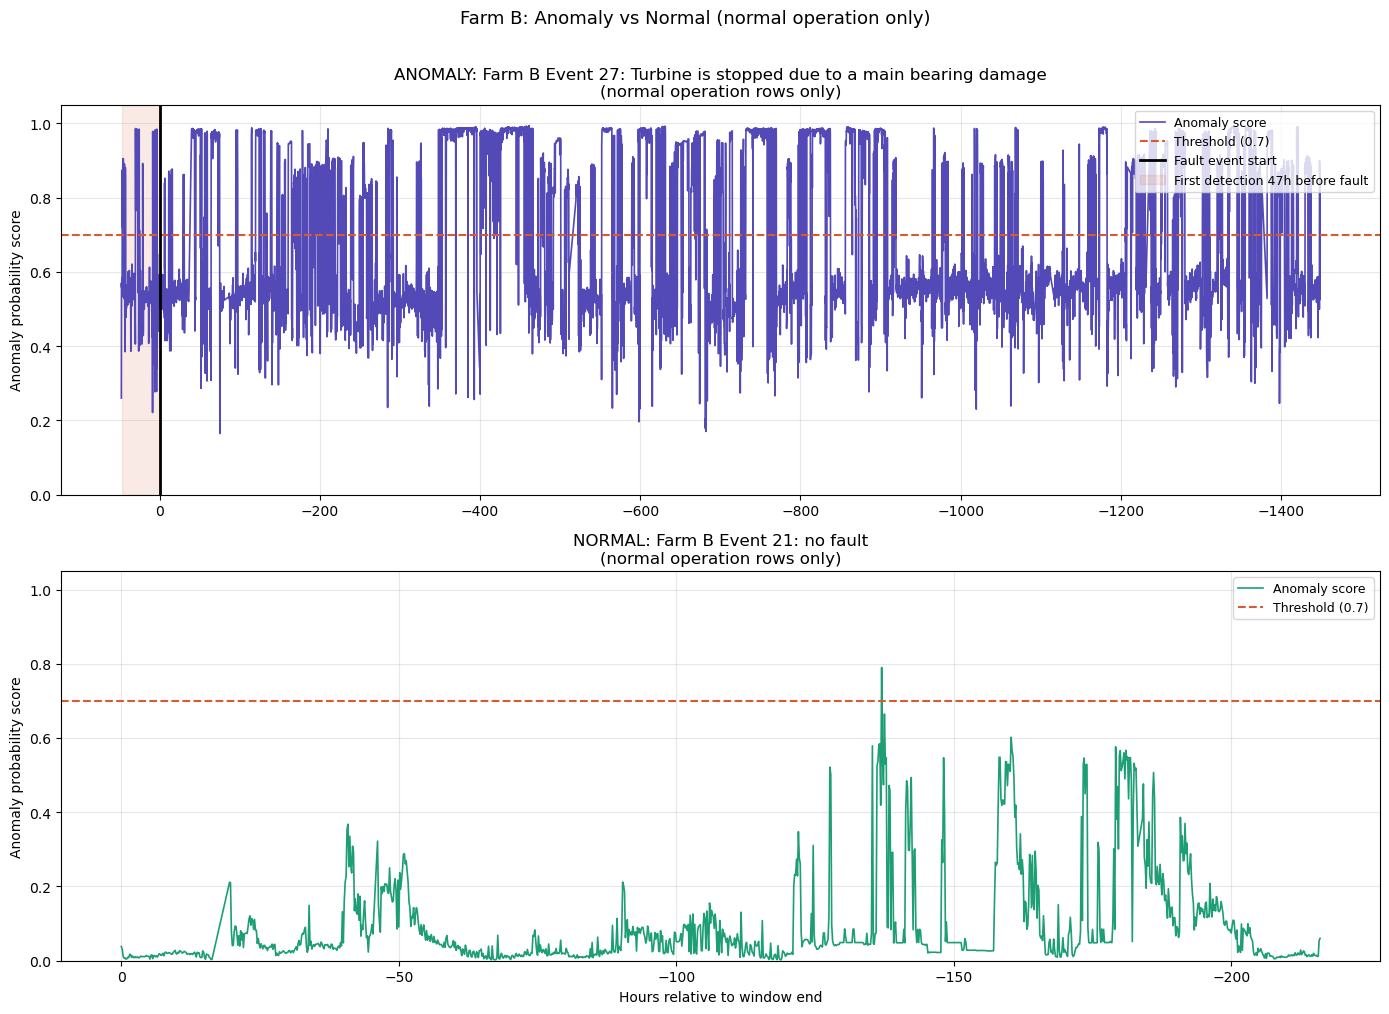

Plot saved as xgb_b_anomaly_vs_normal_filtered.png


In [17]:
# ---------------------------------------------------------------
# Farm B: Anomaly score over time
# Filtered to normal operation rows only (status_type_id == 0)
# to remove oscillation caused by turbine state changes
# ---------------------------------------------------------------

threshold_b = 0.7

pred_b_eng["score"]      = probs_b
pred_b_eng["predicted"]  = (probs_b >= threshold_b).astype(int)
pred_b_eng["time_stamp"] = pd.to_datetime(pred_b_eng["time_stamp"])

event_times_b                = event_info_b[["event_id", "event_start"]].copy()
event_times_b["event_start"] = pd.to_datetime(event_times_b["event_start"])

# Only merge if hours_to_event not already in pred_b_eng
if "hours_to_event" not in pred_b_eng.columns:
    pred_b_eng = pred_b_eng.merge(event_times_b, on="event_id", how="left")
    pred_b_eng["hours_to_event"] = (
        (pred_b_eng["event_start"] - pred_b_eng["time_stamp"])
        .dt.total_seconds() / 3600
    )

# Filter to normal operation only before finding best event
pred_b_active = pred_b_eng[pred_b_eng["status_type_id"] == 0].copy()

print(f"Total pred rows:          {len(pred_b_eng):,}")
print(f"Normal operation rows:    {len(pred_b_active):,}")
print(f"Rows filtered out:        {len(pred_b_eng) - len(pred_b_active):,}")

# Find anomaly event with earliest clean detection
best_b_id    = None
best_b_hours = -999

for eid in pred_b_active[
    pred_b_active["event_label"] == "anomaly"
]["event_id"].unique():
    detected = pred_b_active[
        (pred_b_active["event_id"] == eid) &
        (pred_b_active["score"] >= threshold_b) &
        (pred_b_active["hours_to_event"] > 0)
    ]
    if len(detected) > 0:
        earliest = detected["hours_to_event"].max()
        if earliest > best_b_hours:
            best_b_hours = earliest
            best_b_id    = eid

# Pick a normal event to compare against
normal_b_ids = pred_b_active[
    pred_b_active["event_label"] == "normal"
]["event_id"].unique()
normal_b_id  = normal_b_ids[0] if len(normal_b_ids) > 0 else None

if best_b_id is not None:
    anomaly_plot = pred_b_active[
        pred_b_active["event_id"] == best_b_id
    ].sort_values("hours_to_event", ascending=False)

    fault_desc = event_info_b[
        event_info_b["event_id"] == best_b_id
    ]["event_description"].values[0]

    fig, axes = plt.subplots(
        2 if normal_b_id is not None else 1,
        1, figsize=(14, 10 if normal_b_id is not None else 5)
    )
    if normal_b_id is None:
        axes = [axes]

    # Top — anomaly event
    ax = axes[0]
    ax.plot(
        anomaly_plot["hours_to_event"],
        anomaly_plot["score"],
        color="#534AB7", linewidth=1.2, label="Anomaly score"
    )
    ax.axhline(y=threshold_b, color="#D85A30", linestyle="--",
               linewidth=1.5, label=f"Threshold ({threshold_b})")
    ax.axvline(x=0, color="black", linestyle="-",
               linewidth=2, label="Fault event start")

    detected = anomaly_plot[
        (anomaly_plot["score"] >= threshold_b) &
        (anomaly_plot["hours_to_event"] > 0)
    ]
    if len(detected) > 0:
        ax.axvspan(
            0, detected["hours_to_event"].max(),
            alpha=0.12, color="#D85A30",
            label=f"First detection {best_b_hours:.0f}h before fault"
        )

    ax.set_title(
        f"ANOMALY: Farm B Event {best_b_id}: {fault_desc}\n"
        f"(normal operation rows only)"
    )
    ax.set_ylabel("Anomaly probability score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()

    # Bottom — normal event
    if normal_b_id is not None:
        normal_plot = pred_b_active[
            pred_b_active["event_id"] == normal_b_id
        ].sort_values("hours_to_event", ascending=False)

        ax2 = axes[1]
        ax2.plot(
            normal_plot["hours_to_event"],
            normal_plot["score"],
            color="#1D9E75", linewidth=1.2, label="Anomaly score"
        )
        ax2.axhline(y=threshold_b, color="#D85A30", linestyle="--",
                    linewidth=1.5, label=f"Threshold ({threshold_b})")
        ax2.set_title(
            f"NORMAL: Farm B Event {normal_b_id}: no fault\n"
            f"(normal operation rows only)"
        )
        ax2.set_ylabel("Anomaly probability score")
        ax2.set_xlabel("Hours relative to window end")
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc="upper right", fontsize=9)
        ax2.grid(alpha=0.3)
        ax2.invert_xaxis()

        normal_above  = (normal_plot["score"] >= threshold_b).mean()
        anomaly_above = (anomaly_plot["score"] >= threshold_b).mean()
        print(f"\nAnomaly event: % rows above threshold: {anomaly_above*100:.1f}%")
        print(f"Normal event: % rows above threshold: {normal_above*100:.1f}%")
        print(f"Separation:                             {(anomaly_above - normal_above)*100:.1f} pp")
        print(f"First detection:                        {best_b_hours:.1f}h before fault")

    plt.suptitle(
        "Farm B: Anomaly vs Normal (normal operation only)",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig("xgb_b_anomaly_vs_normal_filtered.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved as xgb_b_anomaly_vs_normal_filtered.png")
else:
    print("No Farm B detections, try lowering threshold")

In [12]:
print("=" * 55)
print("MODEL 2: Farm C XGBoost")
print("=" * 55)

# Farm C training uses Farm C data + Farm B data for volume
# since Farm B has similar fault types (bearing, transformer)
# We rename Farm B sensors to match Farm C naming convention

rename_b_to_c = {
    "sensor_34_avg":  "sensor_186_avg",   # gearbox oil temp
    "sensor_35_avg":  "sensor_187_avg",   # gearbox oil temp 2
    "sensor_38_avg":  "sensor_189_avg",   # gearbox oil inlet temp
    "sensor_32_avg":  "sensor_196_avg",   # bearing temp 1
    "sensor_33_avg":  "sensor_197_avg",   # bearing temp 2
    "sensor_31_avg":  "sensor_191_avg",   # transformer temp
    "sensor_25_avg":  "sensor_144_avg",   # rotor speed
    "sensor_8_avg":   "sensor_177_avg",   # outside temp
    "sensor_6_avg":   "wind_speed_235_avg", # wind speed
}

# Rename Farm B training data to Farm C sensor names
train_b_for_c = train_b.rename(columns=rename_b_to_c)

# Keep only columns that exist in Farm C sensor list
keep_for_c = [c for c in farm_c_sensors
              if c in train_b_for_c.columns or c in train_c.columns]

train_b_for_c_clean = train_b_for_c[
    [c for c in keep_for_c if c in train_b_for_c.columns] +
    ["label", "asset_id", "event_id", "time_stamp", "train_test", "event_label"]
].copy()

# Combine Farm C + renamed Farm B for training
train_c_combined = pd.concat(
    [train_c, train_b_for_c_clean], ignore_index=True
)

# Engineer features
print("\nEngineering Farm C training features...")
train_c_eng = engineer_features(train_c_combined, farm_c_sensors)
train_c_eng = add_zscores(train_c_eng, train_c_eng, farm_c_sensors)

# Engineer Farm C prediction features
print("Engineering Farm C prediction features...")
pred_c_eng  = engineer_features(pred_c, farm_c_sensors)
pred_c_eng  = add_zscores(pred_c_eng, train_c_eng, farm_c_sensors)

# Build feature matrix
c_features  = build_feature_list(farm_c_sensors)
c_features  = [f for f in c_features if f in train_c_eng.columns]

X_train_c   = train_c_eng[c_features].fillna(0)
y_train_c   = train_c_eng["label"].values
X_pred_c    = pred_c_eng[c_features].fillna(0)
y_pred_c    = pred_c_eng["label"].values

print(f"\nFarm C features:        {len(c_features)}")
print(f"Farm C training rows:   {len(X_train_c):,}")
print(f"Farm C prediction rows: {len(X_pred_c):,}")

# Class imbalance
c_normal  = (y_train_c == 0).sum()
c_anomaly = (y_train_c == 1).sum()
c_spw     = c_normal / c_anomaly
print(f"\nscale_pos_weight: {c_spw:.2f}")

# Train
print("\nTraining Farm C model...")
model_c = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = c_spw,
    eval_metric      = "aucpr",
    random_state     = 42,
    n_jobs           = -1
)
model_c.fit(X_train_c, y_train_c, verbose=50,
            eval_set=[(X_train_c, y_train_c)])
print("Farm C model trained.")

MODEL 2: Farm C XGBoost

Engineering Farm C training features...


C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_mean_24h"] = groups[col].transform(
C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_delta"] = groups[col].transform(
C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

Engineering Farm C prediction features...


C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_mean_24h"] = groups[col].transform(
C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_delta"] = groups[col].transform(
C:\Users\cjcha\AppData\Local\Temp\ipykernel_18688\1504800726.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan


Farm C features:        150
Farm C training rows:   3,815,545
Farm C prediction rows: 158,528

scale_pos_weight: 1.21

Training Farm C model...
[0]	validation_0-aucpr:0.60602
[50]	validation_0-aucpr:0.72617
[100]	validation_0-aucpr:0.78778
[150]	validation_0-aucpr:0.82531
[200]	validation_0-aucpr:0.84517
[250]	validation_0-aucpr:0.85903
[299]	validation_0-aucpr:0.87033
Farm C model trained.


Farm C Accuracy: 69.8%

Detailed breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.72      0.66      0.69     80639
 Anomaly (1)       0.68      0.73      0.70     77889

    accuracy                           0.70    158528
   macro avg       0.70      0.70      0.70    158528
weighted avg       0.70      0.70      0.70    158528



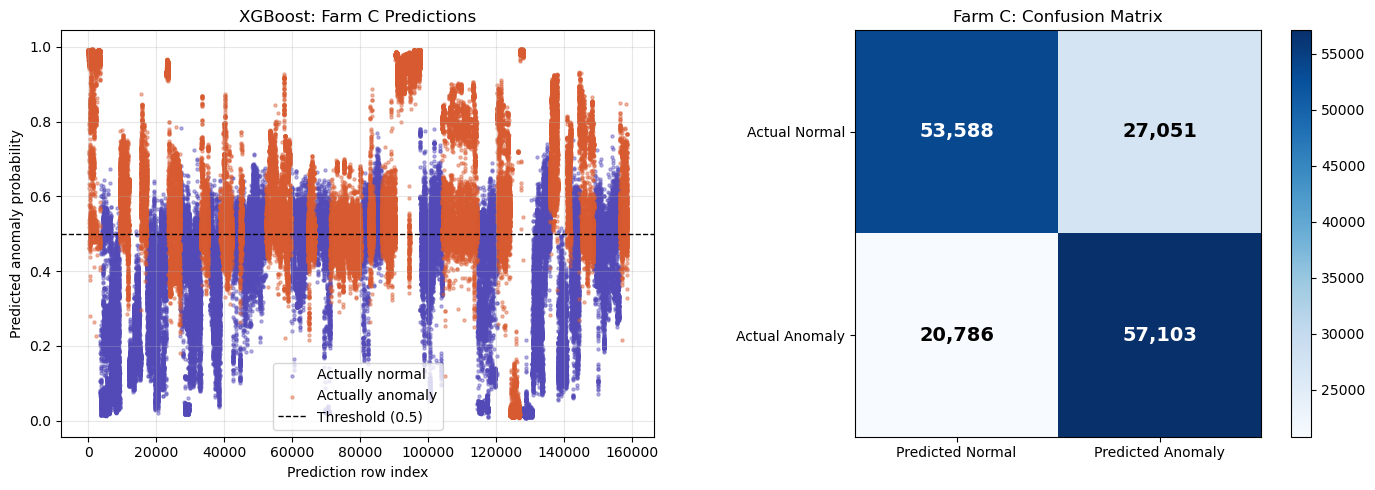

In [13]:
preds_c = model_c.predict(X_pred_c)
probs_c = model_c.predict_proba(X_pred_c)[:, 1]
acc_c   = accuracy_score(y_pred_c, preds_c)

print(f"Farm C Accuracy: {acc_c*100:.1f}%")
print("\nDetailed breakdown:")
print(classification_report(
    y_pred_c, preds_c,
    target_names=["Normal (0)", "Anomaly (1)"]
))

cm_c = confusion_matrix(y_pred_c, preds_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_mask_c  = y_pred_c == 0
anomaly_mask_c = y_pred_c == 1

axes[0].scatter(
    np.where(normal_mask_c)[0],  probs_c[normal_mask_c],
    color="#534AB7", alpha=0.4, s=5, label="Actually normal"
)
axes[0].scatter(
    np.where(anomaly_mask_c)[0], probs_c[anomaly_mask_c],
    color="#D85A30", alpha=0.4, s=5, label="Actually anomaly"
)
axes[0].axhline(y=0.5, color="black", linestyle="--",
                linewidth=1, label="Threshold (0.5)")
axes[0].set_xlabel("Prediction row index")
axes[0].set_ylabel("Predicted anomaly probability")
axes[0].set_title("XGBoost: Farm C Predictions")
axes[0].legend()
axes[0].grid(alpha=0.3)

im = axes[1].imshow(cm_c, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Predicted Normal", "Predicted Anomaly"])
axes[1].set_yticklabels(["Actual Normal", "Actual Anomaly"])
axes[1].set_title("Farm C: Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, f"{cm_c[i,j]:,}", ha="center", va="center",
            color="white" if cm_c[i,j] > cm_c.max()/2 else "black",
            fontsize=14, fontweight="bold"
        )
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("xgb_c_results.png", dpi=150, bbox_inches="tight")
plt.show()

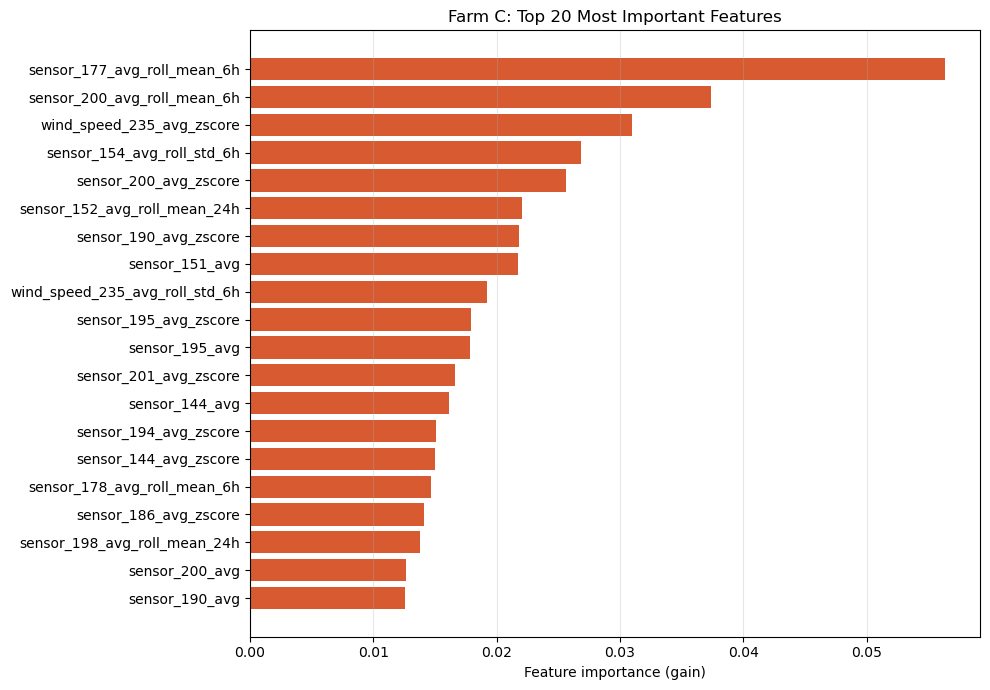

Top 10 Farm C features:
                       feature  importance
   sensor_177_avg_roll_mean_6h    0.056343
   sensor_200_avg_roll_mean_6h    0.037330
     wind_speed_235_avg_zscore    0.030989
    sensor_154_avg_roll_std_6h    0.026861
         sensor_200_avg_zscore    0.025659
  sensor_152_avg_roll_mean_24h    0.022062
         sensor_190_avg_zscore    0.021802
                sensor_151_avg    0.021715
wind_speed_235_avg_roll_std_6h    0.019198
         sensor_195_avg_zscore    0.017921


In [14]:
c_importance = pd.DataFrame({
    "feature":    c_features,
    "importance": model_c.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20_c = c_importance.head(20)
ax.barh(
    top20_c["feature"][::-1],
    top20_c["importance"][::-1],
    color="#D85A30", edgecolor="none"
)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Farm C: Top 20 Most Important Features")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_c_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 Farm C features:")
print(c_importance[["feature", "importance"]].head(10).to_string(index=False))

Total pred rows:          158,528
Normal operation rows:    139,647
Rows filtered out:        18,881

Anomaly event: % rows above threshold: 9.5%
Normal event: % rows above threshold: 0.0%
Separation:                             9.5 pp
First detection:                        66.8h before fault


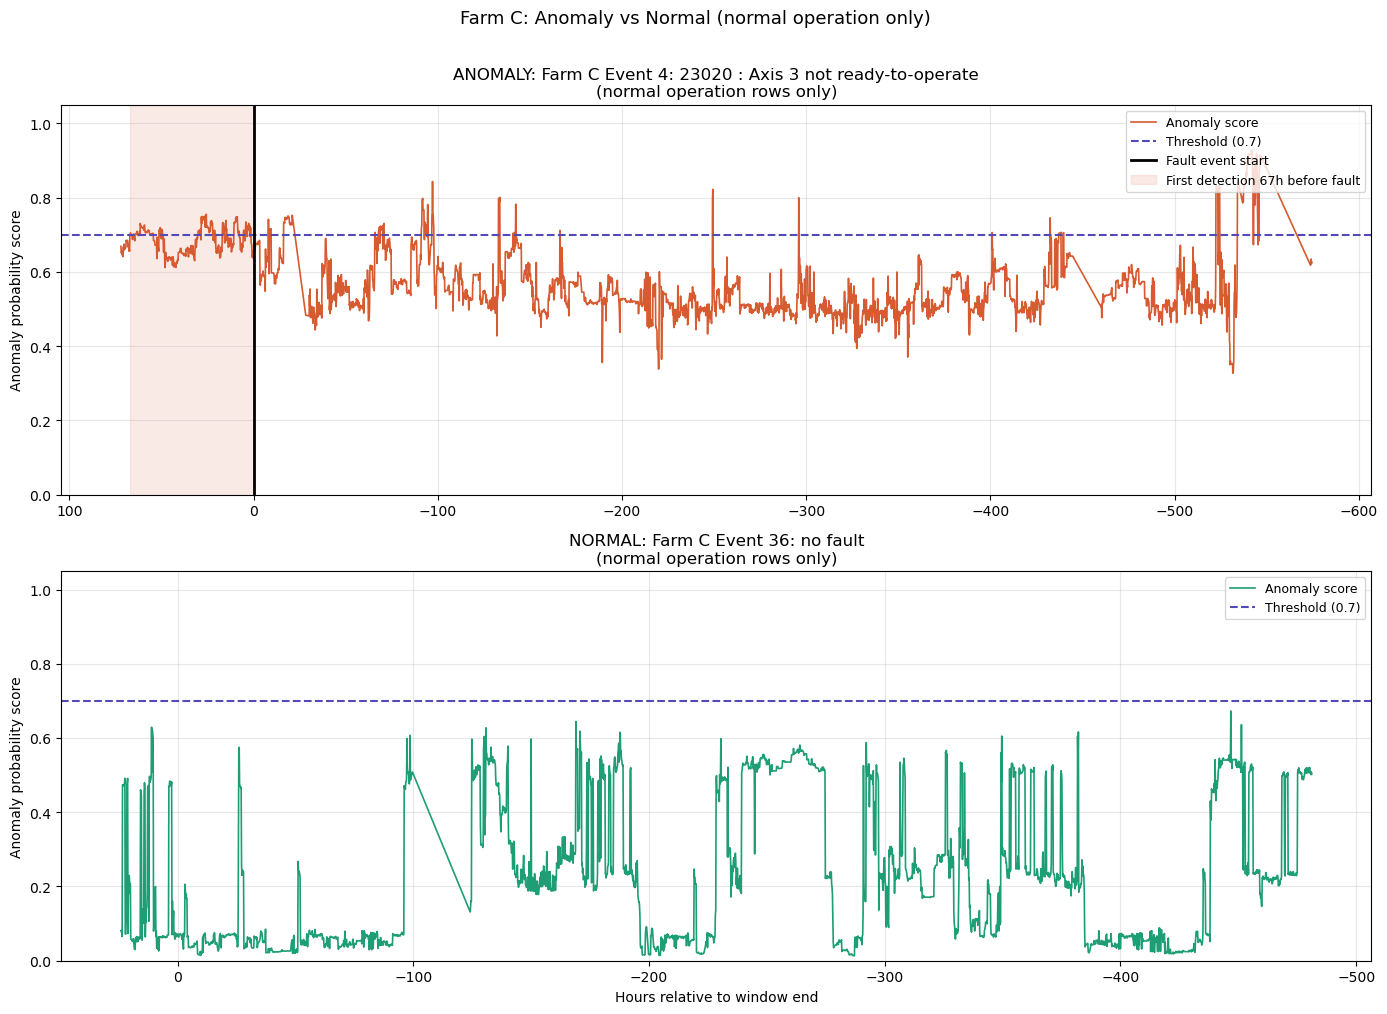

Plot saved as xgb_c_anomaly_vs_normal_filtered.png


In [18]:

# ---------------------------------------------------------------
# Farm C: Anomaly score over time
# Filtered to normal operation rows only (status_type_id == 0)
# to remove oscillation caused by turbine state changes
# ---------------------------------------------------------------

threshold_c = 0.7

pred_c_eng["score"]      = probs_c
pred_c_eng["predicted"]  = (probs_c >= threshold_c).astype(int)
pred_c_eng["time_stamp"] = pd.to_datetime(pred_c_eng["time_stamp"])

event_times_c                = event_info_c[["event_id", "event_start"]].copy()
event_times_c["event_start"] = pd.to_datetime(event_times_c["event_start"])

# Only merge if hours_to_event not already in pred_c_eng
if "hours_to_event" not in pred_c_eng.columns:
    pred_c_eng = pred_c_eng.merge(event_times_c, on="event_id", how="left")
    pred_c_eng["hours_to_event"] = (
        (pred_c_eng["event_start"] - pred_c_eng["time_stamp"])
        .dt.total_seconds() / 3600
    )

# Filter to normal operation only
pred_c_active = pred_c_eng[pred_c_eng["status_type_id"] == 0].copy()

print(f"Total pred rows:          {len(pred_c_eng):,}")
print(f"Normal operation rows:    {len(pred_c_active):,}")
print(f"Rows filtered out:        {len(pred_c_eng) - len(pred_c_active):,}")

# Find anomaly event with earliest clean detection
best_c_id    = None
best_c_hours = -999

for eid in pred_c_active[
    pred_c_active["event_label"] == "anomaly"
]["event_id"].unique():
    detected = pred_c_active[
        (pred_c_active["event_id"] == eid) &
        (pred_c_active["score"] >= threshold_c) &
        (pred_c_active["hours_to_event"] > 0)
    ]
    if len(detected) > 0:
        earliest = detected["hours_to_event"].max()
        if earliest > best_c_hours:
            best_c_hours = earliest
            best_c_id    = eid

# Pick a normal event to compare against
normal_c_ids = pred_c_active[
    pred_c_active["event_label"] == "normal"
]["event_id"].unique()
normal_c_id  = normal_c_ids[0] if len(normal_c_ids) > 0 else None

if best_c_id is not None:
    anomaly_plot_c = pred_c_active[
        pred_c_active["event_id"] == best_c_id
    ].sort_values("hours_to_event", ascending=False)

    fault_desc_c = event_info_c[
        event_info_c["event_id"] == best_c_id
    ]["event_description"].values[0]

    fig, axes = plt.subplots(
        2 if normal_c_id is not None else 1,
        1, figsize=(14, 10 if normal_c_id is not None else 5)
    )
    if normal_c_id is None:
        axes = [axes]

    # Top: anomaly event
    ax = axes[0]
    ax.plot(
        anomaly_plot_c["hours_to_event"],
        anomaly_plot_c["score"],
        color="#D85A30", linewidth=1.2, label="Anomaly score"
    )
    ax.axhline(y=threshold_c, color="#534AB7", linestyle="--",
               linewidth=1.5, label=f"Threshold ({threshold_c})")
    ax.axvline(x=0, color="black", linestyle="-",
               linewidth=2, label="Fault event start")

    detected_c = anomaly_plot_c[
        (anomaly_plot_c["score"] >= threshold_c) &
        (anomaly_plot_c["hours_to_event"] > 0)
    ]
    if len(detected_c) > 0:
        ax.axvspan(
            0, detected_c["hours_to_event"].max(),
            alpha=0.12, color="#D85A30",
            label=f"First detection {best_c_hours:.0f}h before fault"
        )

    ax.set_title(
        f"ANOMALY: Farm C Event {best_c_id}: {fault_desc_c}\n"
        f"(normal operation rows only)"
    )
    ax.set_ylabel("Anomaly probability score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()

    # Bottom — normal event
    if normal_c_id is not None:
        normal_plot_c = pred_c_active[
            pred_c_active["event_id"] == normal_c_id
        ].sort_values("hours_to_event", ascending=False)

        ax2 = axes[1]
        ax2.plot(
            normal_plot_c["hours_to_event"],
            normal_plot_c["score"],
            color="#1D9E75", linewidth=1.2, label="Anomaly score"
        )
        ax2.axhline(y=threshold_c, color="#534AB7", linestyle="--",
                    linewidth=1.5, label=f"Threshold ({threshold_c})")
        ax2.set_title(
            f"NORMAL: Farm C Event {normal_c_id}: no fault\n"
            f"(normal operation rows only)"
        )
        ax2.set_ylabel("Anomaly probability score")
        ax2.set_xlabel("Hours relative to window end")
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc="upper right", fontsize=9)
        ax2.grid(alpha=0.3)
        ax2.invert_xaxis()

        normal_above_c  = (normal_plot_c["score"] >= threshold_c).mean()
        anomaly_above_c = (anomaly_plot_c["score"] >= threshold_c).mean()
        print(f"\nAnomaly event: % rows above threshold: {anomaly_above_c*100:.1f}%")
        print(f"Normal event: % rows above threshold: {normal_above_c*100:.1f}%")
        print(f"Separation:                             {(anomaly_above_c - normal_above_c)*100:.1f} pp")
        print(f"First detection:                        {best_c_hours:.1f}h before fault")

    plt.suptitle(
        "Farm C: Anomaly vs Normal (normal operation only)",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig("xgb_c_anomaly_vs_normal_filtered.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved as xgb_c_anomaly_vs_normal_filtered.png")
else:
    print("No Farm C detections, try lowering threshold")

In [16]:
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
tn_c, fp_c, fn_c, tp_c = cm_c.ravel()

precision_b = tp_b / max(tp_b + fp_b, 1)
recall_b    = tp_b / max(tp_b + fn_b, 1)
precision_c = tp_c / max(tp_c + fp_c, 1)
recall_c    = tp_c / max(tp_c + fn_c, 1)

print("=" * 60)
print("FINAL COMPARISON: FARM B vs FARM C SEPARATE MODELS")
print("=" * 60)
print(f"\n{'Metric':<35} {'Farm B':>10} {'Farm C':>10}")
print("-" * 58)
print(f"{'Accuracy':<35} {acc_b*100:>9.1f}% {acc_c*100:>9.1f}%")
print(f"{'Precision':<35} {precision_b*100:>9.1f}% {precision_c*100:>9.1f}%")
print(f"{'Recall':<35} {recall_b*100:>9.1f}% {recall_c*100:>9.1f}%")
print(f"{'True Positives':<35} {tp_b:>10,} {tp_c:>10,}")
print(f"{'False Negatives (missed)':<35} {fn_b:>10,} {fn_c:>10,}")
print(f"{'False Positives (false alarms)':<35} {fp_b:>10,} {fp_c:>10,}")
print(f"{'Features used':<35} {len(b_features):>10} {len(c_features):>10}")

if best_b_id is not None:
    print(f"\nFarm B earliest detection: {best_b_hours:.1f}h before fault")
if best_c_id is not None:
    print(f"Farm C earliest detection: {best_c_hours:.1f}h before fault")

print("\nTop 3 Farm B features:")
for _, row in b_importance.head(3).iterrows():
    print(f"  {row['feature']:40s} {row['importance']:.4f}")

print("\nTop 3 Farm C features:")
for _, row in c_importance.head(3).iterrows():
    print(f"  {row['feature']:40s} {row['importance']:.4f}")

print("\nSaved plots:")
print("  xgb_b_results.png")
print("  xgb_b_feature_importance.png")
print("  xgb_b_anomaly_timeseries.png")
print("  xgb_c_results.png")
print("  xgb_c_feature_importance.png")
print("  xgb_c_anomaly_timeseries.png")
print("=" * 60)

FINAL COMPARISON: FARM B vs FARM C SEPARATE MODELS

Metric                                  Farm B     Farm C
----------------------------------------------------------
Accuracy                                 86.2%      69.8%
Precision                                83.3%      67.9%
Recall                                   92.5%      73.3%
True Positives                          35,435     57,103
False Negatives (missed)                 2,874     20,786
False Positives (false alarms)           7,095     27,051
Features used                               84        150

Farm B earliest detection: 72.0h before fault
Farm C earliest detection: 66.8h before fault

Top 3 Farm B features:
  sensor_25_avg_zscore                     0.0709
  sensor_20_avg_zscore                     0.0416
  sensor_25_avg                            0.0406

Top 3 Farm C features:
  sensor_177_avg_roll_mean_6h              0.0563
  sensor_200_avg_roll_mean_6h              0.0373
  wind_speed_235_avg_zscore       